In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib

import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu') 
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner

# jax device count: 4


In [2]:
TESS_offset = 2457000

In [3]:
### get the best fit params and param bounds from the 3_jnkep_minimizer_fit file
import pickle
file_name = 'mcmc_runs/1339_jnkep_initial_fit_data_hessian_tree-11_accept-95_emax-0.5_RV.pkl'

with open(file_name, 'rb') as f:
    data = pickle.load(f)

popt = data['popt']
param_bounds = data['param_bounds']
jttv = data['jttv']


/opt/homebrew/anaconda3/envs/tess-old/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


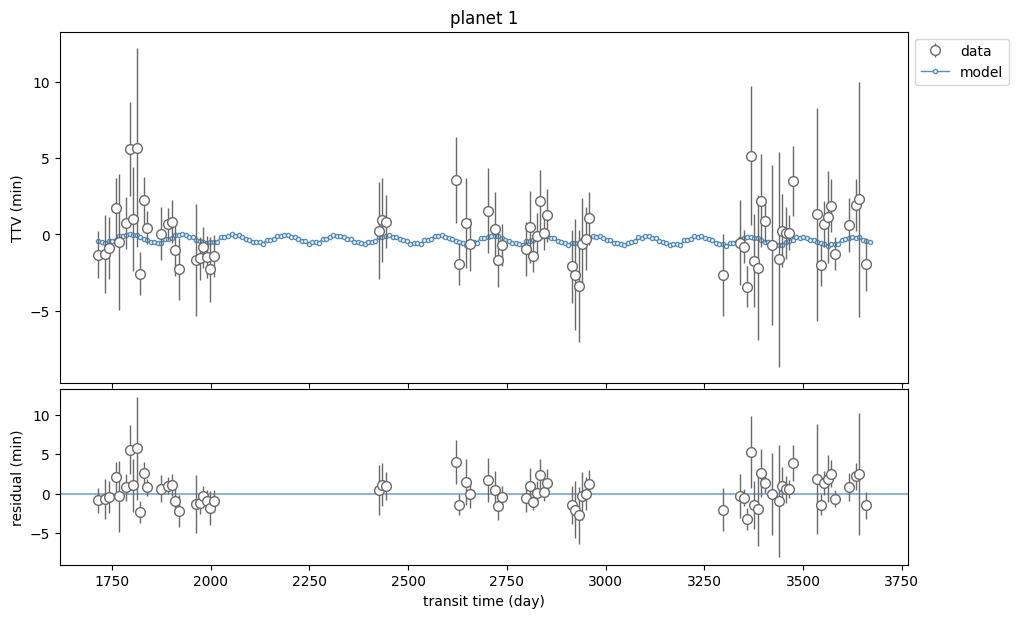

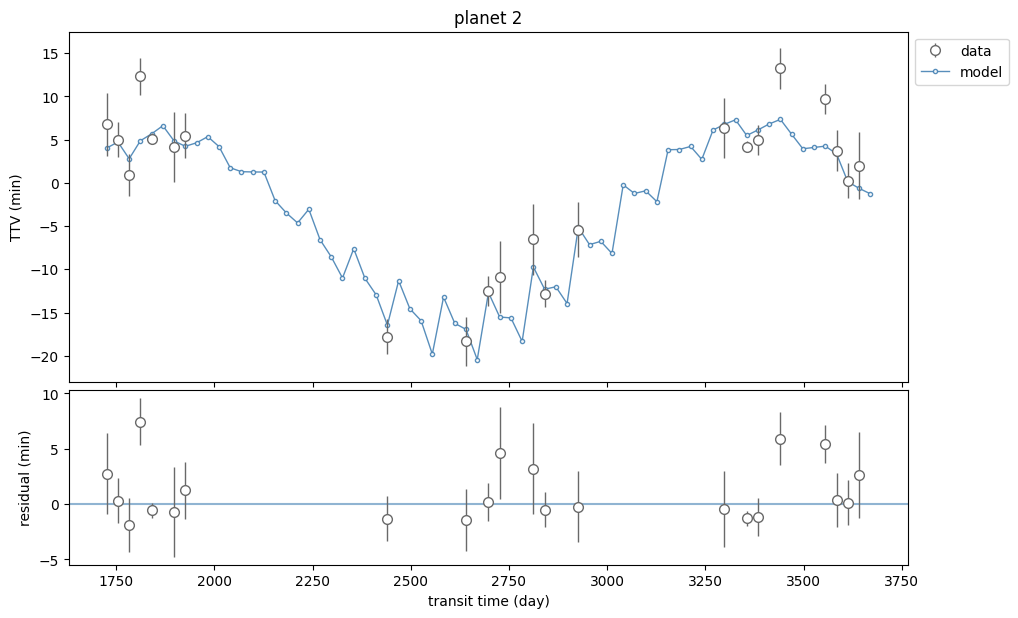

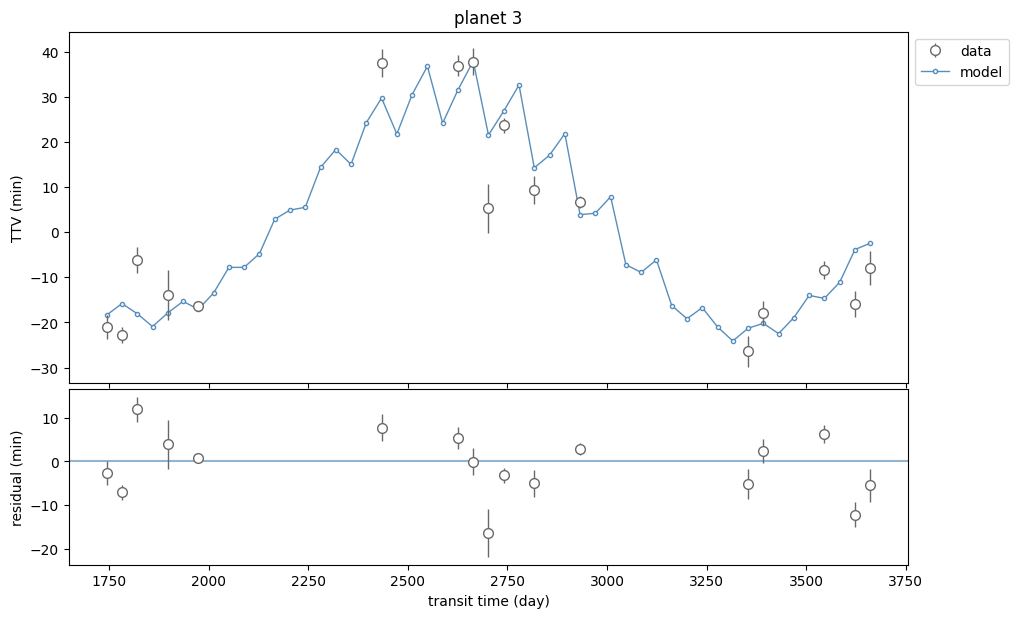

In [4]:
### plot fit
tcall = jttv.get_transit_times_all_list(popt,truncate=False)
jttv.plot_model(tcall, marker='.')
plt.show()

# Load RV data fron Lubin et al 2024

In [5]:
rv_data_file = "data_1339/ajad79edt3_mrt.txt"

colnames = ["BJD", "RVel", "e_RVel", "Inst", "Source", "Source_extra"]

df_rv = pd.read_csv(
    rv_data_file,
    sep=r"\s+",              # regex: split on 1+ whitespace
    comment="#",
    names=colnames,
    skiprows=31,
    engine="python",         # more flexible parser
)

# Merge Source + Source_extra
df_rv["Source"] = df_rv["Source"].fillna("") + " " + df_rv["Source_extra"].fillna("")
df_rv["Source"] = df_rv["Source"].str.strip()

# Drop the helper column
df_rv = df_rv.drop(columns=["Source_extra"])

print(df_rv.head())
print(df_rv)

            BJD   RVel  e_RVel      Inst Source
0  2.458801e+06  -8.18    3.31  CARMENES      A
1  2.458803e+06 -21.22    1.22     HIRES      B
2  2.458804e+06 -10.72    4.05  CARMENES      A
3  2.458815e+06 -11.45    2.52  CARMENES      A
4  2.458816e+06 -26.36    1.19     HIRES      B
              BJD   RVel  e_RVel      Inst     Source
0    2.458801e+06  -8.18    3.31  CARMENES          A
1    2.458803e+06 -21.22    1.22     HIRES          B
2    2.458804e+06 -10.72    4.05  CARMENES          A
3    2.458815e+06 -11.45    2.52  CARMENES          A
4    2.458816e+06 -26.36    1.19     HIRES          B
..            ...    ...     ...       ...        ...
535  2.459869e+06  10.37    2.99       APF          C
536  2.459906e+06  14.99    2.99       APF          C
537  2.460068e+06   4.15    1.89     HIRES  This work
538  2.460095e+06  -9.90    2.27     HIRES  This work
539  2.460488e+06 -31.43    0.99     HIRES  This work

[540 rows x 5 columns]


In [6]:
### convert to TESS time offset 
tess_offset_times = df_rv['BJD'] - TESS_offset
df_rv['BJD'] = tess_offset_times
print(df_rv)

            BJD   RVel  e_RVel      Inst     Source
0    1801.32215  -8.18    3.31  CARMENES          A
1    1802.79992 -21.22    1.22     HIRES          B
2    1804.37441 -10.72    4.05  CARMENES          A
3    1815.30234 -11.45    2.52  CARMENES          A
4    1815.77873 -26.36    1.19     HIRES          B
..          ...    ...     ...       ...        ...
535  2868.96530  10.37    2.99       APF          C
536  2905.85163  14.99    2.99       APF          C
537  3068.11741   4.15    1.89     HIRES  This work
538  3095.04327  -9.90    2.27     HIRES  This work
539  3487.88545 -31.43    0.99     HIRES  This work

[540 rows x 5 columns]


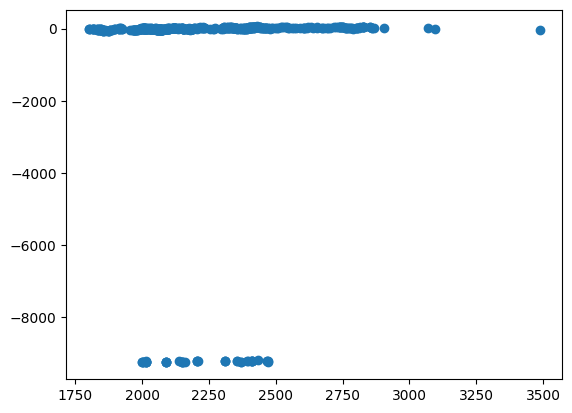

In [23]:
plt.scatter(df_rv['BJD'], df_rv['RVel'])
plt.show()

# print(df_rv['RVel'][df_rv['RVel']<-100])
# print(df_rv['Inst'][df_rv['RVel']<-100])
# print(df_rv['Source'][df_rv['RVel']<-100])



Excluding 42 points from HARPS-N


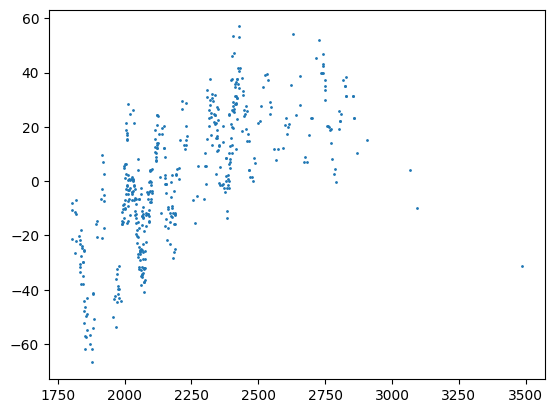

            BJD   RVel  e_RVel      Inst     Source
0    1801.32215  -8.18    3.31  CARMENES          A
1    1802.79992 -21.22    1.22     HIRES          B
2    1804.37441 -10.72    4.05  CARMENES          A
3    1815.30234 -11.45    2.52  CARMENES          A
4    1815.77873 -26.36    1.19     HIRES          B
..          ...    ...     ...       ...        ...
535  2868.96530  10.37    2.99       APF          C
536  2905.85163  14.99    2.99       APF          C
537  3068.11741   4.15    1.89     HIRES  This work
538  3095.04327  -9.90    2.27     HIRES  This work
539  3487.88545 -31.43    0.99     HIRES  This work

[498 rows x 5 columns]


In [25]:
# exclude outliers
print(f'Excluding {len(df_rv['RVel'][df_rv['RVel']<-100])} points from HARPS-N')

df_rv_trimmed = df_rv[df_rv['RVel']>-100]
plt.scatter(df_rv_trimmed['BJD'], df_rv_trimmed['RVel'], s=1)
plt.show()

print(df_rv_trimmed)

# Set up and run HMC

In [48]:
def model_scaled(sample_keys, param_bounds):
    """numpyro model for scaled parameters"""
    par = {}

    # sample parameters from priors
    for key in sample_keys:
        par[key+"_scaled"] = numpyro.sample(key+"_scaled", dist.Uniform(param_bounds[key][0]*0, param_bounds[key][0]*0+1.))
        par[key] = numpyro.deterministic(key, par[key+"_scaled"] * (param_bounds[key][1] - param_bounds[key][0]) + param_bounds[key][0])
    if "pmass" not in sample_keys:
        par["pmass"] = numpyro.deterministic("pmass", jnp.exp(par["lnpmass"]))
    
    # Jacobian for uniform ecc prior
    ecc = numpyro.deterministic("ecc", jnp.sqrt(par['ecosw']**2+par['esinw']**2))
    numpyro.factor("eprior", -jnp.log(ecc))

    # compute transit times
    # tcmodel, ediff = jttv.get_transit_times_obs(par)
    # numpyro.deterministic("ediff", ediff)
    # numpyro.deterministic("tcmodel", tcmodel)

    # compute transit times + RVs
    times_rv = jnp.array(df_rv_trimmed["BJD"].values)  # times in TESS offset days
    tcmodel, rvmodel, ediff = jttv.get_transit_times_and_rvs_obs(par, times_rv, transit_orbit_idx=np.array([0,1,2]))
    numpyro.deterministic("ediff", ediff)
    numpyro.deterministic("tcmodel", tcmodel)
    numpyro.deterministic("rvmodel", rvmodel)

    
    # TTV likelihood
    tcerrmodel = jttv.errorobs_flatten     
    numpyro.sample("obs", dist.Normal(loc=tcmodel, scale=tcerrmodel), obs=jttv.tcobs_flatten)

    # RV likelihood
    rv_obs = jnp.array(df_rv_trimmed["RVel"].values)
    rv_err = jnp.array(df_rv_trimmed["e_RVel"].values)
    numpyro.sample("obs_rv",
                   dist.Normal(loc=rvmodel, scale=rv_err),
                   obs=rv_obs)

In [49]:
# physical parameters to sample from
sample_keys = ["ecosw", "esinw", "pmass", "period", "tic"] # uniform mass prior

In [50]:
# scaled parameters
pdic_scaled = scale_pdic(popt, param_bounds)

In [51]:
### initializing mass matrix
# information matrix and parameter covariance
from jnkepler.jaxttv.information import information
fisher_information = information(jttv, popt, sample_keys)
parameter_cov = jnp.linalg.inv(fisher_information)

for i,key in enumerate(sample_keys):
    print(key, np.diag(jnp.sqrt(parameter_cov))[3*i:3*i+3])

# Fisher information and parameter covariance matrix for scaled parameters
fisher_information_scaled = information(jttv, popt, sample_keys, param_bounds=param_bounds)
parameter_cov_scaled = jnp.linalg.inv(fisher_information_scaled)

# initialize inverse mass matrix using parameter covariance
dense_mass = [tuple([key+"_scaled" for key in sample_keys])]
inverse_mass_matrix = {dense_mass[0]: parameter_cov_scaled}

ecosw [0.27318685 0.14187683 0.12245983]
esinw [0.40207257 0.23602038 0.2029263 ]
pmass [1.90324154e-05 2.34633117e-06 1.62022941e-06]
period [7.85289652e-05 5.30767438e-04 1.23533464e-03]
tic [0.0003091  0.00062762 0.00080503]
computing scaled information matrix.


In [52]:
kernel = NUTS(model_scaled, 
            init_strategy=init_to_value(values=pdic_scaled), 
            dense_mass=dense_mass,
            inverse_mass_matrix=inverse_mass_matrix,
            target_accept_prob=0.95,
            max_tree_depth=11
            #regularize_mass_matrix=False # this speeds up sampling for unknown reason
            )

In [53]:
mcmc = MCMC(kernel, num_warmup=50, num_samples=150, num_chains=num_chains)

In [54]:
# 4hr30min on M1 mac studio
rng_key = random.PRNGKey(0)
mcmc.run(rng_key, sample_keys, param_bounds, extra_fields=('potential_energy', 'num_steps', 'adapt_state'))

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [55]:
mcmc.print_summary()


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      1.00      0.00      1.00      1.00      1.00      2.84      3.53
 ecosw_scaled[1]      0.13      0.08      0.10      0.04      0.27      3.44      2.91
 ecosw_scaled[2]      0.18      0.07      0.15      0.10      0.31      3.71      2.80
 esinw_scaled[0]      0.99      0.01      1.00      0.97      1.00       nan      2.14
 esinw_scaled[1]      0.94      0.05      0.96      0.84      0.99      5.82      2.26
 esinw_scaled[2]      0.92      0.06      0.94      0.81      0.98      5.45      2.34
period_scaled[0]      0.50      0.00      0.50      0.50      0.50      3.06      2.93
period_scaled[1]      0.51      0.00      0.51      0.50      0.51      3.68      2.67
period_scaled[2]      0.50      0.00      0.50      0.50      0.50     10.63      1.98
 pmass_scaled[0]      0.02      0.01      0.02      0.01      0.03      2.56      3.70
 pmass_scaled[1]      0.01      0.00      

In [56]:
# save results
import dill
with open("1339_jnkep_fit_fullls.pkl", "wb") as f:
    dill.dump(mcmc, f)